
# **Dataset Context**
This dataset contains information related to NYPD responses to various incidents. It aims to provide insights into the nature, frequency, and trends of these incidents to improve public safety and resource allocation.

## Key Objectives
- To analyze and understand patterns in NYPD responses.
- To identify areas of high incident frequency.
- To suggest actionable insights for better response planning.



In [ ]:
import pandas as pd
import numpy as np
import requests
import matplotlib.pyplot as plt
import seaborn as sns

# Configurations
sns.set(style="whitegrid")



In [ ]:
# Load dataset
file_path = '/content/FDNY_Monthly_Response_Times_20241119.csv'
data = pd.read_csv(file_path)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6552 entries, 0 to 6551
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   YEARMONTH               6552 non-null   object
 1   INCIDENTCLASSIFICATION  6552 non-null   object
 2   INCIDENTBOROUGH         6552 non-null   object
 3   INCIDENTCOUNT           6552 non-null   int64 
 4   AVERAGERESPONSETIME     6552 non-null   object
dtypes: int64(1), object(4)
memory usage: 256.1+ KB


In [ ]:
# 1. Check for missing values
missing_data = data.isnull().sum()
print("Missing values:\n", missing_data)

Missing values:
 YEARMONTH                 0
INCIDENTCLASSIFICATION    0
INCIDENTBOROUGH           0
INCIDENTCOUNT             0
AVERAGERESPONSETIME       0
dtype: int64


In [ ]:
unique_yearmonths = data['YEARMONTH'].unique()

unique_yearmonths

array(['2009/07', '2009/08', '2009/09', '2009/10', '2009/11', '2009/12',
       '2010/01', '2010/02', '2010/03', '2010/04', '2010/05', '2010/06',
       '2010/07', '2010/08', '2010/09', '2010/10', '2010/11', '2010/12',
       '2011/01', '2011/02', '2011/03', '2011/04', '2011/05', '2011/06',
       '2011/07', '2011/08', '2011/09', '2011/10', '2011/11', '2011/12',
       '2012/01', '2012/02', '2012/03', '2012/04', '2012/05', '2012/06',
       '2012/07', '2012/08', '2012/09', '2012/10', '2012/11', '2012/12',
       '2013/01', '2013/02', '2013/03', '2013/04', '2013/05', '2013/06',
       '2013/07', '2013/08', '2013/09', '2013/10', '2013/11', '2013/12',
       '2014/01', '2014/02', '2014/03', '2014/04', '2014/05', '2014/06',
       '2014/07', '2014/08', '2014/09', '2014/10', '2014/11', '2014/12',
       '2015/01', '2015/02', '2015/03', '2015/04', '2015/05', '2015/06',
       '2015/07', '2015/08', '2015/09', '2015/10', '2015/11', '2015/12',
       '2016/01', '2016/02', '2016/03', '2016/04', 

In [ ]:
# Assuming your original DataFrame is named 'data'
fiscal_year_data = data[data['YEARMONTH'].str.startswith('FY ')]

# Optionally, you can reset the index of the new DataFrame
fiscal_year_data = fiscal_year_data.reset_index(drop=True)

In [ ]:
data.head()

,YEARMONTH,INCIDENTCLASSIFICATION,INCIDENTBOROUGH,INCIDENTCOUNT,AVERAGERESPONSETIME
0,2009/07,All Fire/Emergency Incidents,Citywide,40850,04:27
1,2009/07,All Fire/Emergency Incidents,Manhattan,10709,04:32
2,2009/07,All Fire/Emergency Incidents,Bronx,8137,04:37
3,2009/07,All Fire/Emergency Incidents,Staten Island,2205,04:45
4,2009/07,All Fire/Emergency Incidents,Brooklyn,11505,04:01


# Data Of The Fiscal Year

In [ ]:
fiscal_year_data.head()

,YEARMONTH,INCIDENTCLASSIFICATION,INCIDENTBOROUGH,INCIDENTCOUNT,AVERAGERESPONSETIME
0,FY 2010,All Fire/Emergency Incidents,Citywide,489354,04:33
1,FY 2010,All Fire/Emergency Incidents,Manhattan,125685,04:38
2,FY 2010,All Fire/Emergency Incidents,Bronx,98322,04:44
3,FY 2010,All Fire/Emergency Incidents,Staten Island,27893,04:54
4,FY 2010,All Fire/Emergency Incidents,Brooklyn,137657,04:04


In [ ]:
unique_yearmonths2 = fiscal_year_data['YEARMONTH'].unique()

unique_yearmonths2

array(['FY 2010', 'FY 2011', 'FY 2012', 'FY 2013', 'FY 2014', 'FY 2015',
       'FY 2016', 'FY 2017', 'FY 2018', 'FY 2019', 'FY 2020', 'FY 2021'],
      dtype=object)

In [ ]:
# Assuming your DataFrame is named 'data'
data = data[~data['YEARMONTH'].str.startswith('FY ')]

# Optionally, reset the index:
data = data.reset_index(drop=True)

## I removed the rows representing yearly aggregates (identified by "FY") and focus on the monthly data for your analysis.

In [ ]:
unique_yearmonths = data['YEARMONTH'].unique()

unique_yearmonths

array(['2009/07', '2009/08', '2009/09', '2009/10', '2009/11', '2009/12',
       '2010/01', '2010/02', '2010/03', '2010/04', '2010/05', '2010/06',
       '2010/07', '2010/08', '2010/09', '2010/10', '2010/11', '2010/12',
       '2011/01', '2011/02', '2011/03', '2011/04', '2011/05', '2011/06',
       '2011/07', '2011/08', '2011/09', '2011/10', '2011/11', '2011/12',
       '2012/01', '2012/02', '2012/03', '2012/04', '2012/05', '2012/06',
       '2012/07', '2012/08', '2012/09', '2012/10', '2012/11', '2012/12',
       '2013/01', '2013/02', '2013/03', '2013/04', '2013/05', '2013/06',
       '2013/07', '2013/08', '2013/09', '2013/10', '2013/11', '2013/12',
       '2014/01', '2014/02', '2014/03', '2014/04', '2014/05', '2014/06',
       '2014/07', '2014/08', '2014/09', '2014/10', '2014/11', '2014/12',
       '2015/01', '2015/02', '2015/03', '2015/04', '2015/05', '2015/06',
       '2015/07', '2015/08', '2015/09', '2015/10', '2015/11', '2015/12',
       '2016/01', '2016/02', '2016/03', '2016/04', 

In [ ]:

# # Convert columns to numeric types as needed
data['INCIDENTCOUNT'] = pd.to_numeric(data['INCIDENTCOUNT'], errors='coerce')
data['YEARMONTH'] = pd.to_datetime(data['YEARMONTH'], errors='coerce')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6048 entries, 0 to 6047
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   YEARMONTH               6048 non-null   datetime64[ns]
 1   INCIDENTCLASSIFICATION  6048 non-null   object        
 2   INCIDENTBOROUGH         6048 non-null   object        
 3   INCIDENTCOUNT           6048 non-null   int64         
 4   AVERAGERESPONSETIME     6048 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 236.4+ KB


<ipython-input-191-c1e66f3afdb1>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['YEARMONTH'] = pd.to_datetime(data['YEARMONTH'], errors='coerce')


In [ ]:
import pandas as pd
import dateutil.parser

def convert_to_timedelta(time_str):
    #Try parsing as timestamp using dateutil.parser to ignore timezone
    try:
        dt = dateutil.parser.parse(str(time_str))
        # Return the difference between parsed datetime and 1899-12-31
        return dt - pd.Timestamp('1899-12-31')
    except (ValueError, TypeError):
        try:
            minutes, seconds = map(int, time_str.split(':'))
            return pd.Timedelta(minutes=minutes, seconds=seconds)
        except (ValueError, TypeError):
            print(f"Error parsing: {time_str}")
            return pd.NaT

# Apply the function
data['AVERAGERESPONSETIME'] = data['AVERAGERESPONSETIME'].apply(convert_to_timedelta)

In [ ]:
missing_response_time_rows = data[data['AVERAGERESPONSETIME'].isnull()]
missing_response_time_rows.head()

,YEARMONTH,INCIDENTCLASSIFICATION,INCIDENTBOROUGH,INCIDENTCOUNT,AVERAGERESPONSETIME


In [ ]:
print(data['AVERAGERESPONSETIME'].unique())

<TimedeltaArray>
['45614 days 04:27:00', '45614 days 04:32:00', '45614 days 04:37:00',
 '45614 days 04:45:00', '45614 days 04:01:00', '45614 days 04:43:00',
 '45614 days 04:07:00', '45614 days 04:26:00', '45614 days 03:49:00',
 '45614 days 03:42:00',
 ...
     '0 days 06:22:00',     '0 days 06:06:00',     '0 days 02:28:00',
     '0 days 06:16:00',     '0 days 06:24:00',     '0 days 06:28:00',
     '0 days 07:07:00',     '0 days 06:19:00',     '0 days 06:18:00',
     '0 days 03:58:00']
Length: 326, dtype: timedelta64[ns]


In [ ]:
# 1. Check for missing values
missing_data = data.isnull().sum()
print("Missing values:\n", missing_data)

Missing values:
 YEARMONTH                 0
INCIDENTCLASSIFICATION    0
INCIDENTBOROUGH           0
INCIDENTCOUNT             0
AVERAGERESPONSETIME       0
dtype: int64


In [ ]:
# 2. Handle Missing Values
# Convert any non-numeric 'INCIDENTCOUNT' to NaN and fill it with the median or mean if appropriate
data['INCIDENTCOUNT'].fillna(data['INCIDENTCOUNT'].median(), inplace=True)

<ipython-input-196-8a1cd7b6609f>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['INCIDENTCOUNT'].fillna(data['INCIDENTCOUNT'].median(), inplace=True)


In [ ]:
# 3. Check for duplicates
duplicates = data.duplicated().sum()
print("Duplicates in the dataset:", duplicates)

Duplicates in the dataset: 0


In [ ]:
# Drop duplicates if any are found
if duplicates > 0:
    data = data.drop_duplicates()

# 4. Standardize column names for easier access
data.columns = data.columns.str.lower().str.replace(" ", "_")

# Reconfirm data types after cleaning
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6048 entries, 0 to 6047
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype          
---  ------                  --------------  -----          
 0   yearmonth               6048 non-null   datetime64[ns] 
 1   incidentclassification  6048 non-null   object         
 2   incidentborough         6048 non-null   object         
 3   incidentcount           6048 non-null   int64          
 4   averageresponsetime     6048 non-null   timedelta64[ns]
dtypes: datetime64[ns](1), int64(1), object(2), timedelta64[ns](1)
memory usage: 236.4+ KB


<Axes: title={'center': 'Total Incidents Over Time'}, xlabel='yearmonth'>

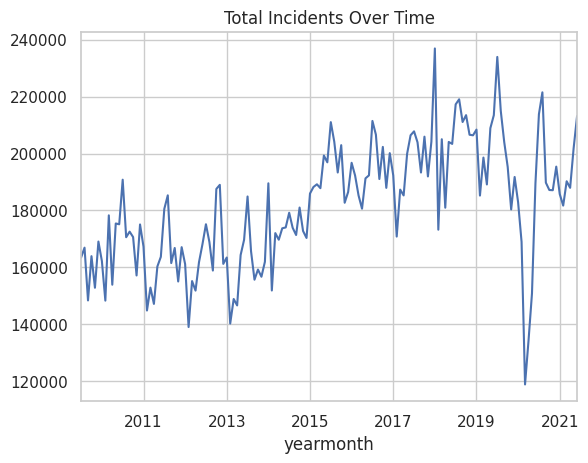

In [ ]:
monthly_data = data.groupby('yearmonth')['incidentcount'].sum()
monthly_data.plot(title='Total Incidents Over Time')


Resource Allocation Needs: Incident types with longer response times may highlight areas where additional resources (like personnel, vehicles, or specialized equipment) are needed. For instance, consistently slow response times for fire emergencies might indicate a need for more fire stations or better equipment in certain areas.

<Axes: title={'center': 'Avg Response Time by Classification'}, xlabel='incidentclassification'>

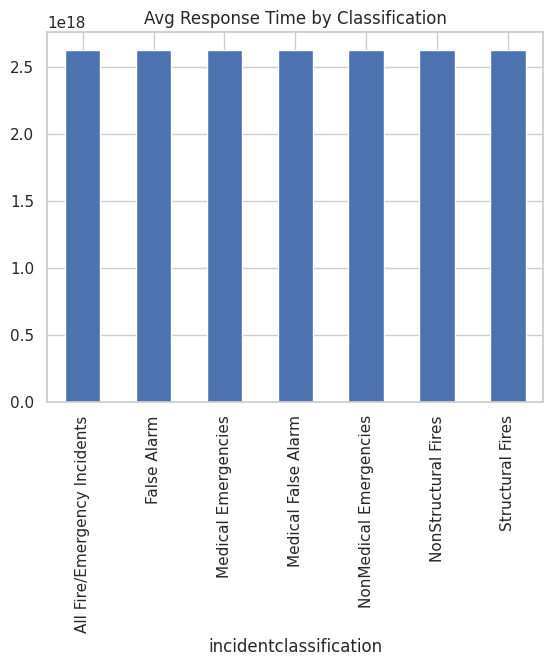

In [ ]:
classification_response_time = data.groupby('incidentclassification')['averageresponsetime'].mean()
classification_response_time.plot(kind='bar', title='Avg Response Time by Classification')


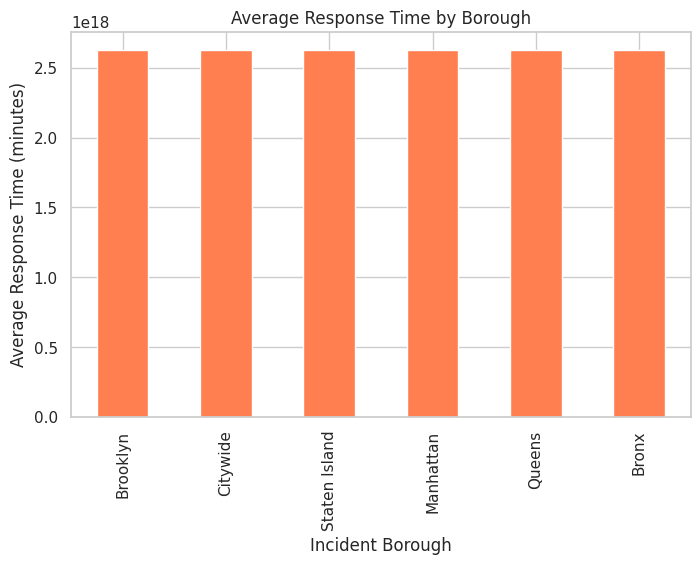

In [ ]:
# Group by 'incidentborough' and calculate average response time
borough_response_time = data.groupby('incidentborough')['averageresponsetime'].mean()
borough_response_time = borough_response_time.sort_values()

plt.figure(figsize=(8, 5))
borough_response_time.plot(kind='bar', color='coral')
plt.title('Average Response Time by Borough')
plt.xlabel('Incident Borough')
plt.ylabel('Average Response Time (minutes)')
plt.show()


<Axes: title={'center': 'Incident Counts by Borough Over Time'}, xlabel='yearmonth'>

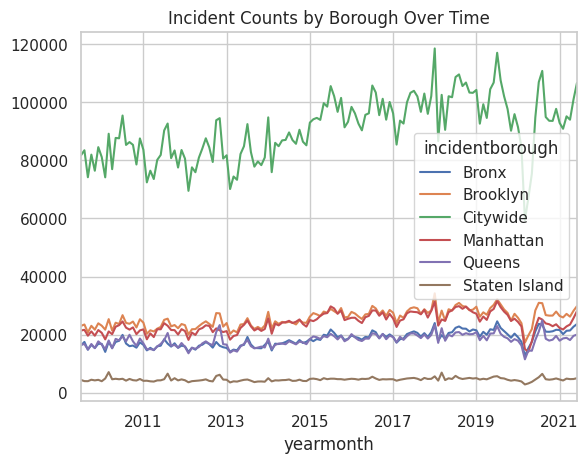

In [ ]:
borough_trends = data.groupby(['yearmonth', 'incidentborough'])['incidentcount'].sum().unstack()
borough_trends.plot(title='Incident Counts by Borough Over Time')


Trend of Average Response Time Over Time

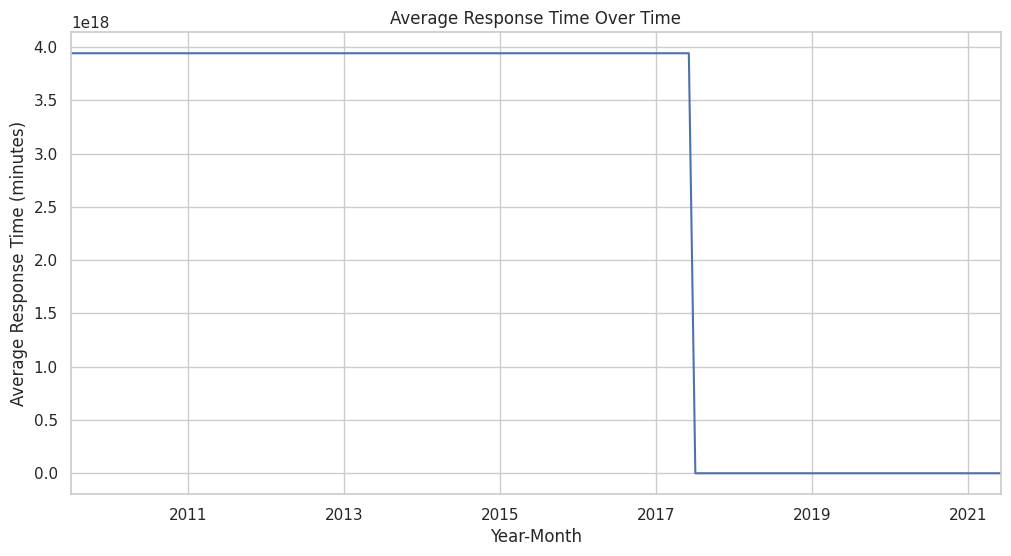

In [ ]:
monthly_response_time = data.groupby('yearmonth')['averageresponsetime'].mean()
plt.figure(figsize=(12, 6))
monthly_response_time.plot(title='Average Response Time Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Average Response Time (minutes)')
plt.show()


Top Incident Classifications by Response Time


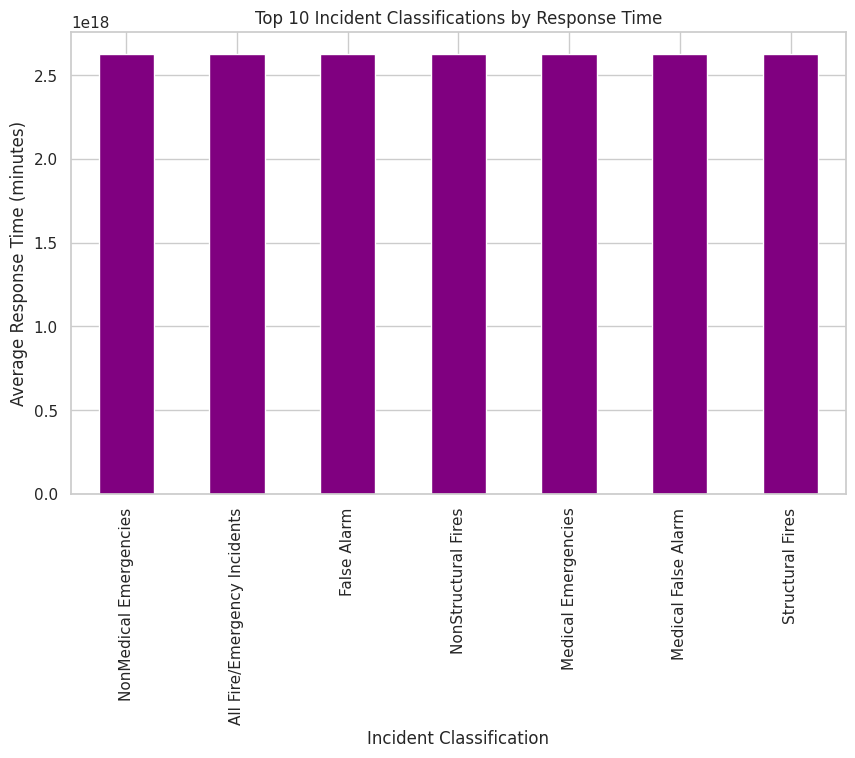

In [ ]:
top_classifications_by_response = data.groupby('incidentclassification')['averageresponsetime'].mean()
top_classifications_by_response = top_classifications_by_response.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_classifications_by_response.plot(kind='bar', color='purple')
plt.title('Top 10 Incident Classifications by Response Time')
plt.xlabel('Incident Classification')
plt.ylabel('Average Response Time (minutes)')
plt.show()


**Comparison of Incident Counts and Response Times by Borough**

Compare total incidents and average response times across boroughs. This can indicate whether higher incident volume correlates with response time challenges.



Incident Density: The boroughs with the highest incident counts likely indicate areas with more frequent emergencies or high population density, which could demand more resources and planning.

Response Time Performance: By comparing average response times across boroughs, you can assess which areas have faster or slower emergency responses. Longer response times could highlight potential inefficiencies or logistical challenges, possibly due to traffic, geographical layout, or resource allocation.

Correlation Between Incident Count and Response Time: If higher incident counts are associated with slower response times, it might suggest that resources are being stretched thin in those areas. Conversely, if high-incident boroughs maintain low response times, it could indicate effective management and resource allocation.

Priority Areas for Improvement: Boroughs with both high incident counts and slower response times could be prioritized for additional resources, better planning, or infrastructure improvements. This insight can guide city planners or emergency services to optimize resource distribution.

Comparative Analysis: Examining outliers, such as boroughs with particularly low or high response times regardless of incident count, could reveal unique factors in certain areas—like proximity to emergency services, efficiency of local teams, or even traffic patterns.


Resource Allocation Effectiveness: If certain boroughs with low incident counts have high response times, it may suggest over-allocation of resources that could potentially be redistributed.

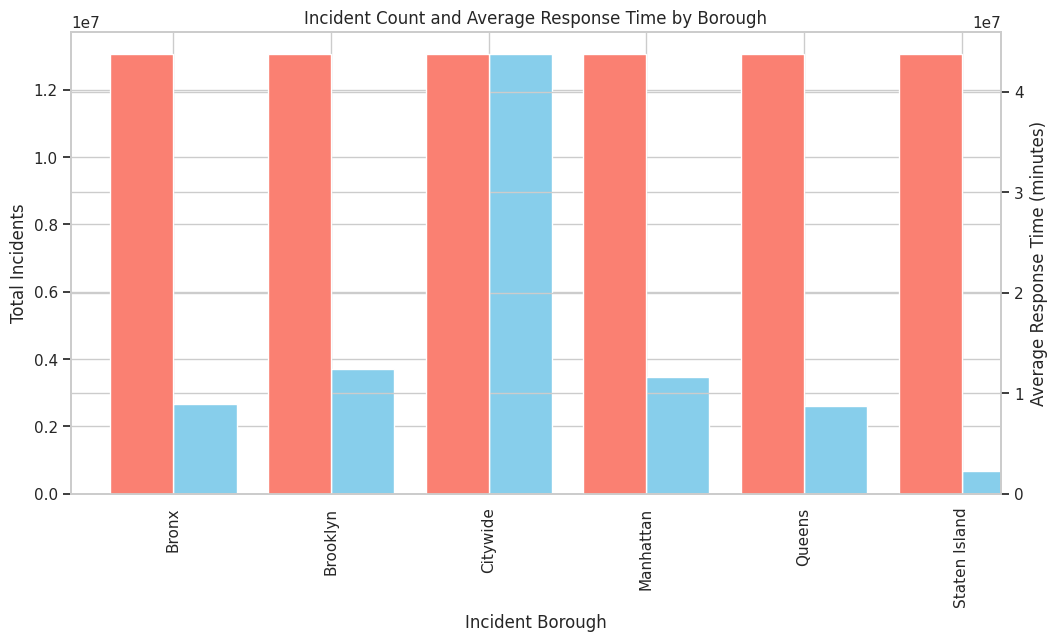

In [ ]:
borough_data = data.groupby('incidentborough').agg(
    total_incidents=('incidentcount', 'sum'),
    avg_response_time=('averageresponsetime', 'mean')
)

fig, ax1 = plt.subplots(figsize=(12, 6))

borough_data['total_incidents'].plot(kind='bar', ax=ax1, color='skyblue', position=0, width=0.4)
ax1.set_ylabel('Total Incidents')
ax1.set_xlabel('Incident Borough')

ax2 = ax1.twinx()
borough_data['avg_response_time'] = borough_data['avg_response_time'].dt.total_seconds() / 60  # Convert to minutes
borough_data['avg_response_time'].plot(kind='bar', ax=ax2, color='salmon', position=1, width=0.4)
ax2.set_ylabel('Average Response Time (minutes)')

plt.title('Incident Count and Average Response Time by Borough')
plt.show()


**Incident Volume and Response Time Correlation by Month**

Analyze if there’s a correlation between incident volume in a month and the average response time, showing if high demand affects response times.

Correlation between Monthly Incident Volume and Average Response Time: -0.4791640026721018


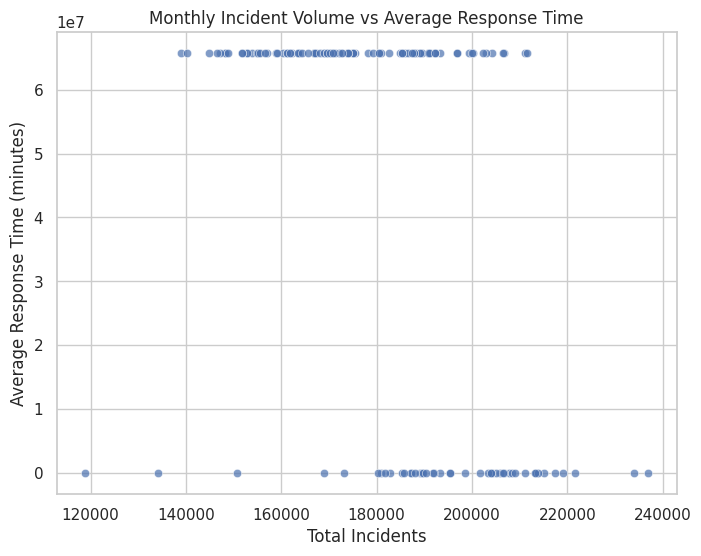

In [ ]:
monthly_data = data.groupby('yearmonth').agg(
    total_incidents=('incidentcount', 'sum'),
    avg_response_time=('averageresponsetime', 'mean')
)

correlation = monthly_data['total_incidents'].corr(monthly_data['avg_response_time'].dt.total_seconds())
print(f"Correlation between Monthly Incident Volume and Average Response Time: {correlation}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=monthly_data['total_incidents'],
                y=monthly_data['avg_response_time'].dt.total_seconds() / 60,
                alpha=0.7)
plt.title('Monthly Incident Volume vs Average Response Time')
plt.xlabel('Total Incidents')
plt.ylabel('Average Response Time (minutes)')
plt.show()


**Weekday vs. Weekend Incident Patterns**

Compare incidents and response times on weekdays vs. weekends to see if there’s a difference in volume or speed.

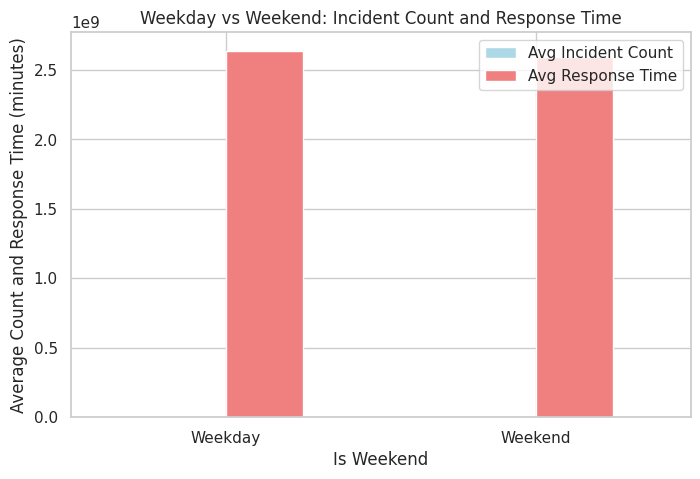

In [ ]:
data['weekday'] = data['yearmonth'].dt.weekday
data['is_weekend'] = data['weekday'].isin([5, 6])

weekday_vs_weekend = data.groupby('is_weekend').agg(
    avg_incidents=('incidentcount', 'mean'),
    avg_response_time=('averageresponsetime', 'mean')
)

weekday_vs_weekend['avg_response_time'] = weekday_vs_weekend['avg_response_time'].dt.total_seconds()  # Convert to minutes

weekday_vs_weekend.plot(kind='bar', color=['lightblue', 'lightcoral'], figsize=(8, 5))
plt.title('Weekday vs Weekend: Incident Count and Response Time')
plt.xlabel('Is Weekend')
plt.xticks([0, 1], ['Weekday', 'Weekend'], rotation=0)
plt.ylabel('Average Count and Response Time (minutes)')
plt.legend(['Avg Incident Count', 'Avg Response Time'])
plt.show()


**Boroughs with Fastest Response Times for Top Incident Types**

For top incident types, identify which boroughs respond fastest. This could reveal borough-specific strengths.

<Figure size 1200x800 with 0 Axes>

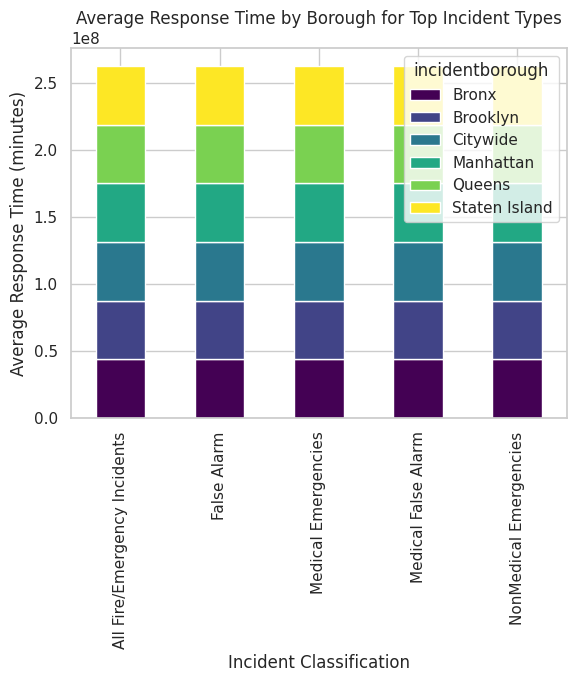

In [ ]:
top_incidents = data['incidentclassification'].value_counts().index[:5]
top_incident_data = data[data['incidentclassification'].isin(top_incidents)]

top_borough_response = top_incident_data.groupby(['incidentclassification', 'incidentborough'])['averageresponsetime'].mean().unstack()
top_borough_response = top_borough_response.apply(lambda x: x.dt.total_seconds() / 60)  # Convert to minutes

plt.figure(figsize=(12, 8))
top_borough_response.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Average Response Time by Borough for Top Incident Types')
plt.xlabel('Incident Classification')
plt.ylabel('Average Response Time (minutes)')
plt.show()


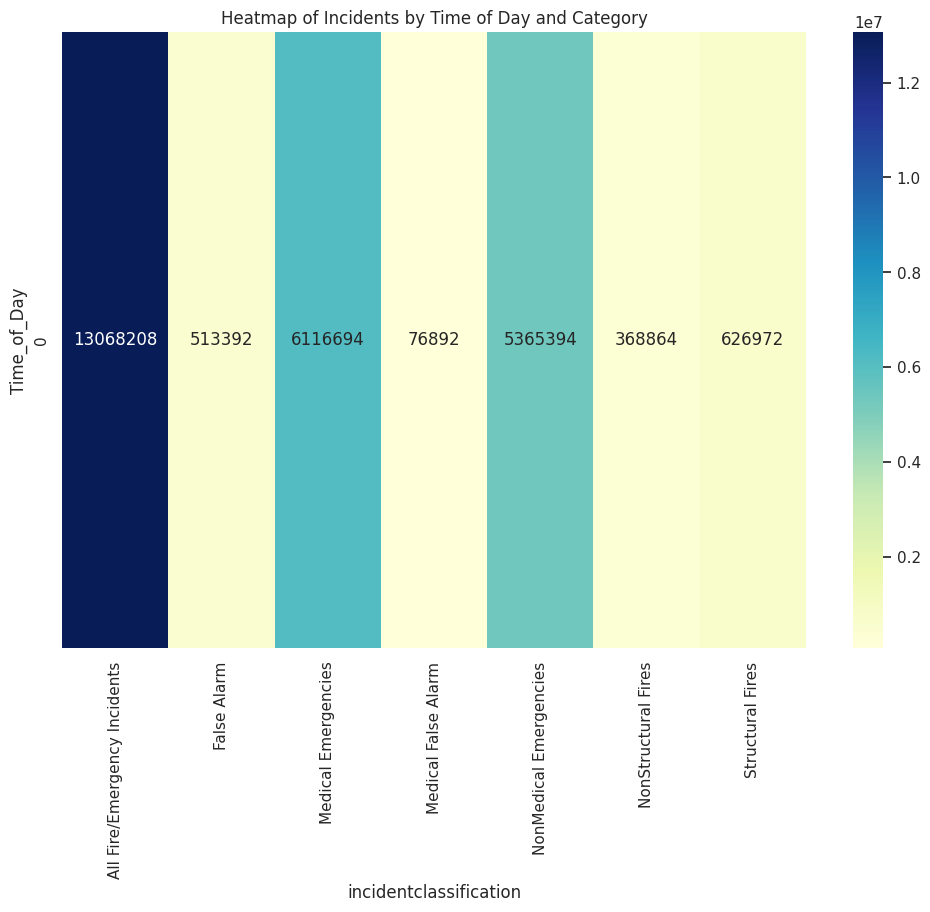

In [ ]:
# Example visualization: Heatmap of incidents by time of day and category
import seaborn as sns
import matplotlib.pyplot as plt

data['Time_of_Day'] = data['yearmonth'].dt.hour

# Create the pivot table using the corrected column name 'Time_of_Day'
heatmap_data = data.pivot_table(index='Time_of_Day', columns='incidentclassification', values='incidentcount', aggfunc='sum')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap of Incidents by Time of Day and Category')
plt.show()


### Heatmap of Incidents by Time of Day and Category
This heatmap visualizes the distribution of incidents across different times of the day and their corresponding categories. The insights help identify:
- Peak hours requiring more resources.
- Categories of incidents that are more frequent at specific times.


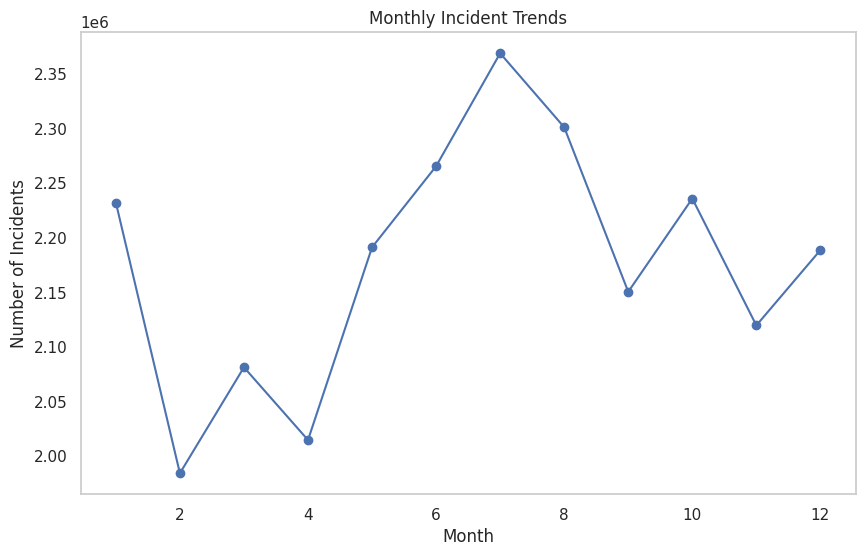

In [ ]:
# Example visualization: Incident trends over months
data['Time_of_Day'] = data['yearmonth'].dt.hour

# Assuming 'yearmonth' contains date information, use that instead of 'Incident_Date'
data['Month'] = data['yearmonth'].dt.month

monthly_trends = data.groupby('Month')['incidentcount'].sum() # Assuming you want to count incidents

plt.figure(figsize=(10, 6))
monthly_trends.plot(kind='line', marker='o')
plt.title('Monthly Incident Trends')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.grid()
plt.show()


### Monthly Incident Trends
This line chart depicts the trends in incidents over the months of a year. Insights:
- Months with the highest and lowest incident frequencies.
- Seasonal patterns influencing incident rates.


In [ ]:
import plotly.express as px

classification_counts = data.groupby('incidentclassification')['incidentcount'].sum().reset_index()

fig = px.pie(
    classification_counts,
    values='incidentcount',
    names='incidentclassification',
    title='Incident Count by Classification',
    hover_data=['incidentcount']
)

# fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(uniformtext_minsize=12, uniformtext_mode='hide')

# Show the chart
fig.show()

In [ ]:
classification_counts

,incidentclassification,incidentcount
0,All Fire/Emergency Incidents,13068208
1,False Alarm,513392
2,Medical Emergencies,6116694
3,Medical False Alarm,76892
4,NonMedical Emergencies,5365394
5,NonStructural Fires,368864
6,Structural Fires,626972


In [ ]:


# Group data by incident borough and sum incident counts
borough_counts = data.groupby('incidentborough')['incidentcount'].sum().reset_index()

# Create the column chart
fig = px.bar(
    borough_counts.sort_values(by=['incidentcount']),

    x='incidentcount',
    y='incidentborough',
    title='Incident Count by Borough',
    hover_data=['incidentcount']  # Include incident count in hover data
)

# Update layout for better display (optional)
fig.update_layout(
    xaxis_title='Incident Borough',
    yaxis_title='Total Incident Count'
)

# Show the chart
fig.show()

In [ ]:
import plotly.express as px

# Group data by incident borough and incident classification, then sum incident counts
borough_classification_counts = data.groupby(['incidentborough', 'incidentclassification'])['incidentcount'].sum().reset_index()

# Create the bar chart
fig = px.bar(
    borough_classification_counts,
    x='incidentborough',
    y='incidentcount',
    color='incidentclassification',
    title='Incident Count by Borough and Classification',
    hover_data=['incidentclassification', 'incidentcount'],  # Include hover data
    labels={'incidentborough': 'Incident Borough', 'incidentcount': 'Total Incident Count', 'incidentclassification': 'Incident Classification'}
)

# Update layout for better display (optional)
fig.update_layout(barmode='stack')  # Stacked bars for easier comparison

# Show the chart
fig.show()

In [ ]:
import plotly.express as px

# Group data by incident borough and incident classification, then sum incident counts
borough_classification_counts = data.groupby(['incidentborough', 'incidentclassification'])['incidentcount'].sum().reset_index()

# Create the bar chart
fig = px.bar(
    borough_classification_counts,
    x='incidentborough',
    y='incidentcount',
    color='incidentclassification',
    title='Incident Count by Borough and Classification',
    hover_data=['incidentclassification', 'incidentcount'],  # Include hover data
    labels={'incidentborough': 'Incident Borough', 'incidentcount': 'Total Incident Count', 'incidentclassification': 'Incident Classification'}
)

# Update layout for better display (optional)
fig.update_layout(barmode='group')  # Grouped bars

# Show the chart
fig.show()